# Phase 1: Parse Log với Drain3

In [115]:
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig
from sklearn.metrics import classification_report
from sklearn.ensemble import IsolationForest
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering












In [116]:
log_file = "Data/HDFS_2k.log"

with open(log_file, "r") as f:
    lines = f.readlines()

print(f"Tổng số dòng: {len(lines)}")

Tổng số dòng: 2000


In [117]:
config = TemplateMinerConfig()
config.drain_sim_th = 0.4        
config.drain_depth = 4   

miner = TemplateMiner(config=config)

# Parse log
for line in lines:
    line = line.strip()
    result = miner.add_log_message(line)
    
# List toàn bộ template
print("Số template: ", len(miner.drain.clusters))    
for cluster in miner.drain.clusters:
    print(f"  [{cluster.cluster_id}] (count={cluster.size}): {cluster.get_template()}")

Số template:  17
  [1] (count=311): <*> <*> <*> INFO dfs.DataNode$PacketResponder: PacketResponder <*> for block <*> terminating
  [2] (count=314): <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: <*> is added to <*> size <*>
  [3] (count=292): <*> <*> <*> INFO dfs.DataNode$PacketResponder: Received block <*> of size <*> from <*>
  [4] (count=292): <*> <*> <*> INFO dfs.DataNode$DataXceiver: Receiving block <*> src: <*> dest: <*>
  [5] (count=115): <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.allocateBlock: <*> <*>
  [6] (count=20): <*> <*> 13 INFO dfs.DataBlockScanner: Verification succeeded for <*>
  [7] (count=263): <*> <*> <*> INFO dfs.FSDataset: Deleting block <*> file <*>
  [8] (count=80): <*> <*> <*> INFO dfs.DataNode$DataXceiver: <*> Served block <*> to <*>
  [9] (count=80): <*> <*> <*> WARN dfs.DataNode$DataXceiver: <*> exception while serving <*> to <*>
  [10] (count=224): <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.delete

In [118]:
# Create folder
if not os.path.exists('results'):
    os.makedirs('results')


data = []
for cluster in miner.drain.clusters:
    data.append({
        "template_id": cluster.cluster_id,
        "template": cluster.get_template(),
        "count": cluster.size
    })

# Get top 10
df = pd.DataFrame(data)
top_10 = df.sort_values(by="count", ascending=False).head(10)

# Export
top_10.to_csv("results/top_templates.csv", index=False)

In [119]:
sim_threshold = [0.3, 0.5, 0.7]
results = []

for threshold in sim_threshold:
    config = TemplateMinerConfig()
    config.drain_sim_th = threshold
    miner = TemplateMiner(config=config)
    
    for line in lines:
        miner.add_log_message(line.strip())
    
    # Note num of template    
    num_templates = len(miner.drain.clusters)
    results.append({"drain_sim_th": threshold, "num_templates": num_templates})

df_tuning = pd.DataFrame(results)
print("Tunning result")
print(df_tuning)

Tunning result
   drain_sim_th  num_templates
0           0.3             17
1           0.5             21
2           0.7            820


Với kết quả thu được sau khi so sánh với log_templates(14 templates) thì với data này 0.3 là mốc threshold tốt nhất. Mốc 0.5 bắt đầu tách ra nhiều template hơn và đến mốc 0.7 thì số lượng template lên đến 820 quá lơn.

# Phase 2: Anomaly Detection trên Log
## Tạo template count time series

In [120]:
# Config theo threshold tốt nhất
config = TemplateMinerConfig()
config.drain_sim_th = 0.3   
miner = TemplateMiner(config=config)

log_entries = []

# Tạo template timeseries
def create_template_timeseries(log_entries, window='5min'):
    df = pd.DataFrame(log_entries, columns=['timestamp', 'template_id'])
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # Group by time window + template → count
    ts = df.groupby([pd.Grouper(key='timestamp', freq=window), 'template_id']).size()
    ts = ts.unstack(fill_value=0)  # pivot: rows=time, cols=template
    
    return ts

# Lấy timestamp
def parse_log_line(line):
    # VD "081109 203615"
    match = re.search(r'^(\d{6})\s+(\d{6})', line)
    if match:
        date_str, time_str = match.groups()
        # Chuyển thành dạng datetime chuẩn 
        try:
            return pd.to_datetime(date_str + time_str, format='%y%m%d%H%M%S')
        except:
            return None
    return None

for line in lines:
    line = line.strip()
    result = miner.add_log_message(line)
    
    ts = parse_log_line(line) 
    
    # Lưu cặp (timestamp, template_id)
    log_entries.append((ts, result['cluster_id']))

df_timeseries = create_template_timeseries(log_entries, window='5min')
print(df_timeseries.head())



template_id          1   2   3   4   5   6   7   8   9   10  11  12  13  14  \
timestamp                                                                     
2008-11-09 20:35:00   2   0   0   0   0   0   0   0   0   0   0   0   0   0   
2008-11-09 20:40:00   2   4   0   0   0   0   0   0   0   0   0   0   0   0   
2008-11-09 20:45:00   1   1   2   3   0   0   0   0   0   0   0   0   0   0   
2008-11-09 20:50:00   1   1   2   0   2   0   0   0   0   0   0   0   0   0   
2008-11-09 20:55:00   0   3   2   1   1   1   0   0   0   0   0   0   0   0   

template_id          15  16  17  
timestamp                        
2008-11-09 20:35:00   0   0   0  
2008-11-09 20:40:00   0   0   0  
2008-11-09 20:45:00   0   0   0  
2008-11-09 20:50:00   0   0   0  
2008-11-09 20:55:00   0   0   0  


## Apply anomaly detector từ D1 (3σ hoặc Isolation Forest) trên template count

In [121]:
X = df_timeseries.drop(
    columns=['anomaly'],
    errors='ignore'
).copy()

X.columns = X.columns.astype(str)

iso = IsolationForest(
    contamination=0.01,
    random_state=42
)

pred = iso.fit_predict(X)
df_timeseries['anomaly'] = pred

anomalies = df_timeseries[
    df_timeseries['anomaly'] == -1
]
print("Number of anomaly windows:", len(anomalies))
print(anomalies.index)


Number of anomaly windows: 4
DatetimeIndex(['2008-11-10 10:30:00', '2008-11-10 10:35:00',
               '2008-11-10 21:00:00', '2008-11-11 06:50:00'],
              dtype='datetime64[ns]', name='timestamp', freq=None)


# Detect: template nào spike bất thường? Template mới xuất hiện khi nào?

In [122]:
# Detect template với spike bất thường
spike_results = []

for ts in anomalies.index:

    row = df_timeseries.loc[ts].drop('anomaly')
    spike_template = row.idxmax()
    spike_count = row.max()

    spike_results.append({
        "timestamp": ts,
        "template_id": spike_template,
        "count": spike_count
    })

spike_df = pd.DataFrame(spike_results)

print("Detected template spikes:")
print(spike_df)

# Detect new template
split_idx = int(len(log_entries) * 0.7)

# Tạm lấy 70% log làm known
known_templates = {
    template_id
    for _, template_id in log_entries[:split_idx]
}

new_template_events = []

# Kiểm tra 30% log còn lại
for ts, template_id in log_entries[split_idx:]:

    if template_id not in known_templates:

        known_templates.add(template_id)

        new_template_events.append({
            "timestamp": ts,
            "template_id": template_id
        })

new_template_df = pd.DataFrame(new_template_events)

print("Number of new templates:", len(new_template_df))

if len(new_template_df) > 0:
    print("\nNew templates detected:")
    print(new_template_df)
else:
    print("\nNo new templates detected.")

Detected template spikes:
            timestamp  template_id  count
0 2008-11-10 10:30:00           10     64
1 2008-11-10 10:35:00            7     45
2 2008-11-10 21:00:00           10     36
3 2008-11-11 06:50:00           10     17
Number of new templates: 5

New templates detected:
            timestamp  template_id
0 2008-11-11 05:03:34           13
1 2008-11-11 06:52:54           14
2 2008-11-11 06:53:03           15
3 2008-11-11 08:09:34           16
4 2008-11-11 09:17:33           17


## Nếu dataset có label (HDFS): tính precision/recall của log-based anomaly detection

In [123]:
log_data = [] 

for line in lines:
    line = line.strip()
    result = miner.add_log_message(line)
    ts = parse_log_line(line) 
    
    # Lấy blk_id
    match_blk = re.search(r'(blk_[-]*\d+)', line)
    blk_id = match_blk.group(1) if match_blk else None
    
    if ts is not None:
        log_data.append({
            'timestamp': ts,
            'template_id': result['cluster_id'],
            'block_id': blk_id
        })

df_full = pd.DataFrame(log_data)

df_timeseries = df_full.pivot_table(
    index=pd.Grouper(key='timestamp', freq='5min'),
    columns='template_id',
    aggfunc='size',
    fill_value=0
)

# Apply IF lại
iso_forest = IsolationForest(n_estimators=100, contamination=0.02, random_state=42)
df_timeseries['anomaly'] = iso_forest.fit_predict(df_timeseries)

# Tính Precision + Recall
df_labels = pd.read_csv('Data/anomaly_label.csv') 
label_map = dict(zip(df_labels['BlockId'], df_labels['Label']))

df_full['label_numeric'] = df_full['block_id'].map(lambda x: -1 if label_map.get(x) == 'Anomaly' else 1)

y_true = df_full.groupby(pd.Grouper(key='timestamp', freq='5min'))['label_numeric'].min()
y_true = y_true.reindex(df_timeseries.index, fill_value=1)
y_pred = df_timeseries['anomaly']

print("Precision/recall của log-based anomaly detection")
print(classification_report(y_true, y_pred, target_names=['Anomaly', 'Normal']))

Precision/recall của log-based anomaly detection
              precision    recall  f1-score   support

     Anomaly       0.57      0.09      0.15        45
      Normal       0.86      0.99      0.92       260

    accuracy                           0.86       305
   macro avg       0.72      0.54      0.54       305
weighted avg       0.82      0.86      0.81       305



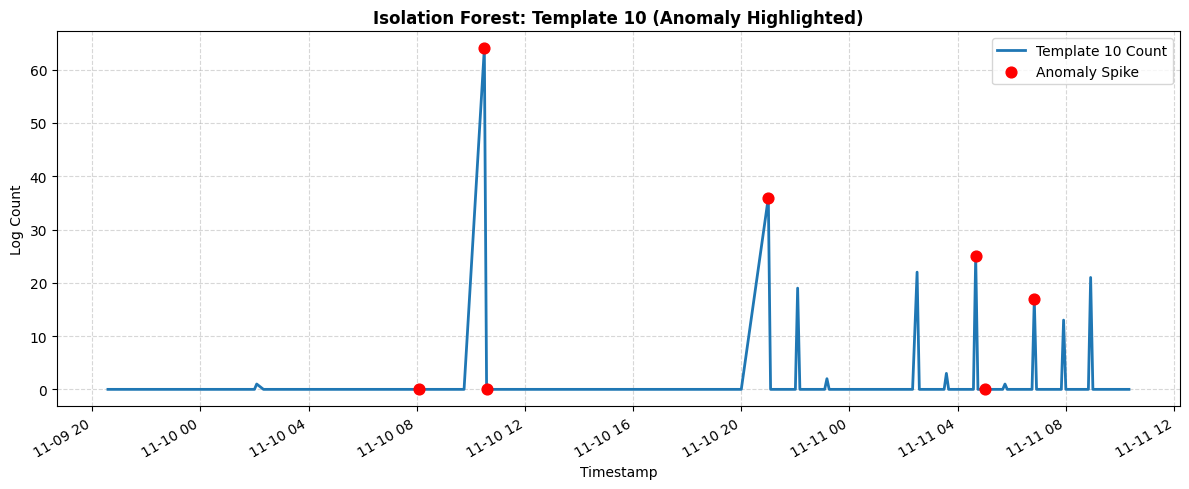

In [124]:
# Plot template count time series, anomaly highlighted
df_anomalies_only = df_timeseries[df_timeseries['anomaly'] == -1].drop(columns=['anomaly'])

# Plot cho template nhiều anomaly nhất để tránh rối
chosen_template = df_anomalies_only.sum().idxmax()

plt.figure(figsize=(12, 5))

plt.plot(df_timeseries.index, df_timeseries[chosen_template], 
         label=f'Template {chosen_template} Count', color='#1f77b4', linewidth=2)

anomalies_indices = df_timeseries[df_timeseries['anomaly'] == -1].index
plt.scatter(anomalies_indices, df_timeseries.loc[anomalies_indices, chosen_template], 
            color='red', s=60, zorder=5, label='Anomaly Spike')

plt.title(f"Isolation Forest: Template {chosen_template} (Anomaly Highlighted)", 
          fontsize=12, fontweight='bold')
plt.ylabel("Log Count")
plt.xlabel("Timestamp")
plt.grid(True, linestyle='--', alpha=0.5)
plt.gcf().autofmt_xdate() 
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Phase 3: Embedding + Cross-signal

In [125]:
templates = [
    c.get_template() if hasattr(c, "get_template") else str(c)
    for c in miner.drain.clusters
]

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(templates)

# Tính similarity matrix
sim_matrix = cosine_similarity(tfidf_matrix)

# Clustering
n_clusters = min(5, len(templates))
clustering = AgglomerativeClustering(n_clusters=n_clusters, metric='cosine', linkage='complete')
cluster_labels = clustering.fit_predict(sim_matrix)

# Các clusters
print("Clusters")
for i in range(n_clusters):
    print(f"\nCluster {i}:")
    for idx, label in enumerate(cluster_labels):
        if label == i:
            print(f" - {templates[idx]}")

# Inject 1 dòng log “lạ” (tự viết, khác tất cả template) → Drain3 tạo new template → detect
log = "081109 203615 ERROR Unauthorized access detected from 10.0.0.1"
result = miner.add_log_message(log)
new_template = result['template_mined']

# Vector hóa template mới 
new_vec = vectorizer.transform([new_template])

# Tính similarity
similarities = cosine_similarity(new_vec, tfidf_matrix)

print(f"Log lạ deteced")
print(f"Template mới: {new_template}")


Clusters

Cluster 0:
 - <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: <*> is added to <*> size <*>
 - <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.allocateBlock: <*> <*>
 - <*> <*> <*> INFO dfs.FSDataset: Deleting block <*> file <*>
 - <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.delete: <*> is added to invalidSet of <*>
 - 081110 <*> 19 INFO dfs.FSNamesystem: BLOCK* ask <*> to delete <*>

Cluster 1:
 - <*> <*> <*> INFO dfs.DataNode$PacketResponder: PacketResponder <*> for block <*> terminating
 - <*> <*> <*> INFO dfs.DataNode$PacketResponder: Received block <*> of size <*> from <*>
 - <*> <*> <*> INFO dfs.DataNode$DataXceiver: Receiving block <*> src: <*> dest: <*>
 - <*> <*> <*> INFO dfs.DataNode$DataXceiver: <*> Served block <*> to <*>
 - <*> <*> <*> WARN dfs.DataNode$DataXceiver: <*> exception while serving <*> to <*>
 - 081111 <*> <*> INFO dfs.DataNode$DataXceiver: Received block <*> src: <*> dest: <*> of size 67108864

Clus

# Phase 4: Challenge — Build Mini Log Analyzer

In [126]:
# HDFS_2k.log
! python log_analyzer.py Data/HDFS_2k.log

Log Analyzer
Total logs: 2000
Unique templates (clusters): 17

Top-5 templates:
- 314 (15.70%) -> [2] <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: <*> is added to <*> size <*>
- 311 (15.55%) -> [1] <*> <*> <*> INFO dfs.DataNode$PacketResponder: PacketResponder <*> for block <*> terminating
- 292 (14.60%) -> [3] <*> <*> <*> INFO dfs.DataNode$PacketResponder: Received block <*> of size <*> from <*>
- 292 (14.60%) -> [4] <*> <*> <*> INFO dfs.DataNode$DataXceiver: Receiving block <*> src: <*> dest: <*>
- 263 (13.15%) -> [7] <*> <*> <*> INFO dfs.FSDataset: Deleting block <*> file <*>

Spike templates:
- [SPIKE] 55 -> [7] <*> <*> <*> INFO dfs.FSDataset: Deleting block <*> file <*>
- [SPIKE] 76 -> [1] <*> <*> <*> INFO dfs.DataNode$PacketResponder: PacketResponder <*> for block <*> terminating
- [SPIKE] 64 -> [4] <*> <*> <*> INFO dfs.DataNode$DataXceiver: Receiving block <*> src: <*> dest: <*>
- [SPIKE] 32 -> [5] <*> <*> <*> INFO dfs.FSNamesystem: BLOC

In [127]:
# Spark_2k.log
! python log_analyzer.py Data/Spark_2k.log

Log Analyzer
Total logs: 2000
Unique templates (clusters): 27

Top-5 templates:
- 375 (18.75%) -> [22] 17/06/09 <*> INFO python.PythonRunner: Times: total = <*> boot = <*> init = <*> finish = <*>
- 305 (15.25%) -> [14] 17/06/09 <*> INFO executor.CoarseGrainedExecutorBackend: Got assigned task <*>
- 305 (15.25%) -> [15] 17/06/09 <*> INFO executor.Executor: Running task <*> in stage <*> (TID <*>
- 300 (15.00%) -> [23] 17/06/09 <*> INFO executor.Executor: Finished task <*> in stage <*> (TID <*> <*> bytes result sent to driver
- 257 (12.85%) -> [24] 17/06/09 <*> INFO storage.BlockManager: Found block <*> locally

Spike templates:
- [SPIKE] 79 -> [23] 17/06/09 <*> INFO executor.Executor: Finished task <*> in stage <*> (TID <*> <*> bytes result sent to driver
- [SPIKE] 80 -> [14] 17/06/09 <*> INFO executor.CoarseGrainedExecutorBackend: Got assigned task <*>
- [SPIKE] 80 -> [15] 17/06/09 <*> INFO executor.Executor: Running task <*> in stage <*> (TID <*>
- [SPIKE] 77 -> [24] 17/06/09 <*> INFO 

Data Spark có nhiều template hơn vì nó chứa nhiều loại sự kiện hơn và có mức độ biến động cao hơn trong quá trình thực thi